In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


In [ ]:
import os
os.environ["KAGGLE USERNAME"]="leodas007000"
os.environ["KAGGLE KEY"]="KGAT_eb6e0cfa78a4b048590f0bb27ccbe17e"

In [ ]:
!kaggle datasets download -d "leodas007000/credit-card-scoring"

Dataset URL: https://www.kaggle.com/datasets/leodas007000/credit-card-scoring
License(s): CC-BY-NC-SA-4.0
100% 511k/511k [00:00<00:00, 46.5MB/s]



In [ ]:
import pandas as pd


df = pd.read_excel("Social_Credit_Scoring_Dataset_10000.csv" )
df.head()


,Age,Annual_Income,Employment_Status,Education,Loan_Repayment,Tax_Payment,Utility_Bill_Payment,Traffic_Violations,Criminal_Record,Community_Service_Hours,Online_Fraud_Complaints,Social_Credit_Score
0,65,475450,Unemployed,Diploma,Late,Paid,Late,6,No,83,3,Poor
1,19,1672440,Full-Time,High School,On Time,Paid,Paid,7,No,81,5,Poor
2,30,652940,Full-Time,High School,On Time,Unpaid,Late,6,No,9,4,Poor
3,33,917925,Unemployed,High School,On Time,Paid,Paid,0,No,45,2,Good
4,46,1054846,Full-Time,Diploma,On Time,Paid,Paid,0,No,22,0,Good


In [ ]:
print("Shape:", df.shape)
df.info()


Shape: (10000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      10000 non-null  int64 
 1   Annual_Income            10000 non-null  int64 
 2   Employment_Status        10000 non-null  object
 3   Education                10000 non-null  object
 4   Loan_Repayment           10000 non-null  object
 5   Tax_Payment              10000 non-null  object
 6   Utility_Bill_Payment     10000 non-null  object
 7   Traffic_Violations       10000 non-null  int64 
 8   Criminal_Record          10000 non-null  object
 9   Community_Service_Hours  10000 non-null  int64 
 10  Online_Fraud_Complaints  10000 non-null  int64 
 11  Social_Credit_Score      10000 non-null  object
dtypes: int64(5), object(7)
memory usage: 937.6+ KB


In [ ]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,10000.0,NaN,NaN,NaN,41.4684,13.831469,18.0,30.0,41.0,53.0,65.0
Annual_Income,10000.0,NaN,NaN,NaN,1098896.7245,519503.356654,200011.0,647171.0,1097119.5,1548111.75,1999773.0
Employment_Status,10000,4,Self-Employed,2533,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,10000,4,Postgraduate,2571,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Loan_Repayment,10000,2,On Time,5001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tax_Payment,10000,2,Paid,5012,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Utility_Bill_Payment,10000,2,Late,5002,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Traffic_Violations,10000.0,NaN,NaN,NaN,3.9834,2.568343,0.0,2.0,4.0,6.0,8.0
Criminal_Record,10000,2,No,8982,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Community_Service_Hours,10000.0,NaN,NaN,NaN,50.2631,29.200818,0.0,25.0,50.0,76.0,100.0


In [ ]:
df.dtypes

,0
Age,int64
Annual_Income,int64
Employment_Status,object
Education,object
Loan_Repayment,object
Tax_Payment,object
Utility_Bill_Payment,object
Traffic_Violations,int64
Criminal_Record,object
Community_Service_Hours,int64


In [ ]:
df.size

120000

In [ ]:

df.isnull().sum()


,0
Age,0
Annual_Income,0
Employment_Status,0
Education,0
Loan_Repayment,0
Tax_Payment,0
Utility_Bill_Payment,0
Traffic_Violations,0
Criminal_Record,0
Community_Service_Hours,0


/tmp/ipykernel_3679/3996321540.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Social_Credit_Score', data=df, order=order, palette='viridis')


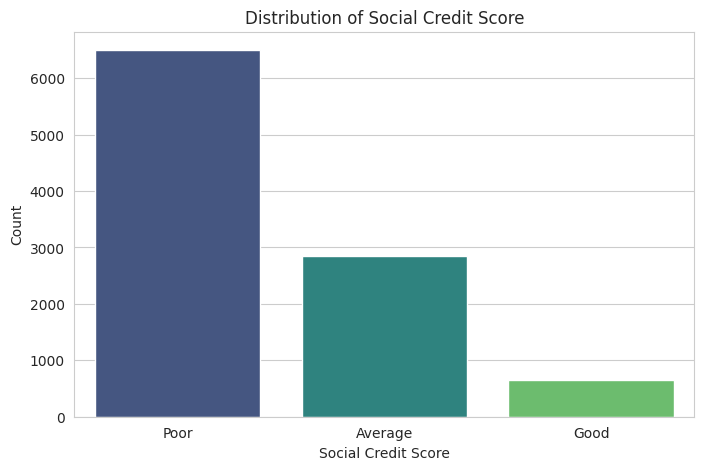

In [ ]:

plt.figure()
order = ['Poor', 'Average', 'Good']
sns.countplot(x='Social_Credit_Score', data=df, order=order, palette='viridis')
plt.title('Distribution of Social Credit Score')
plt.xlabel('Social Credit Score')
plt.ylabel('Count')
plt.show()


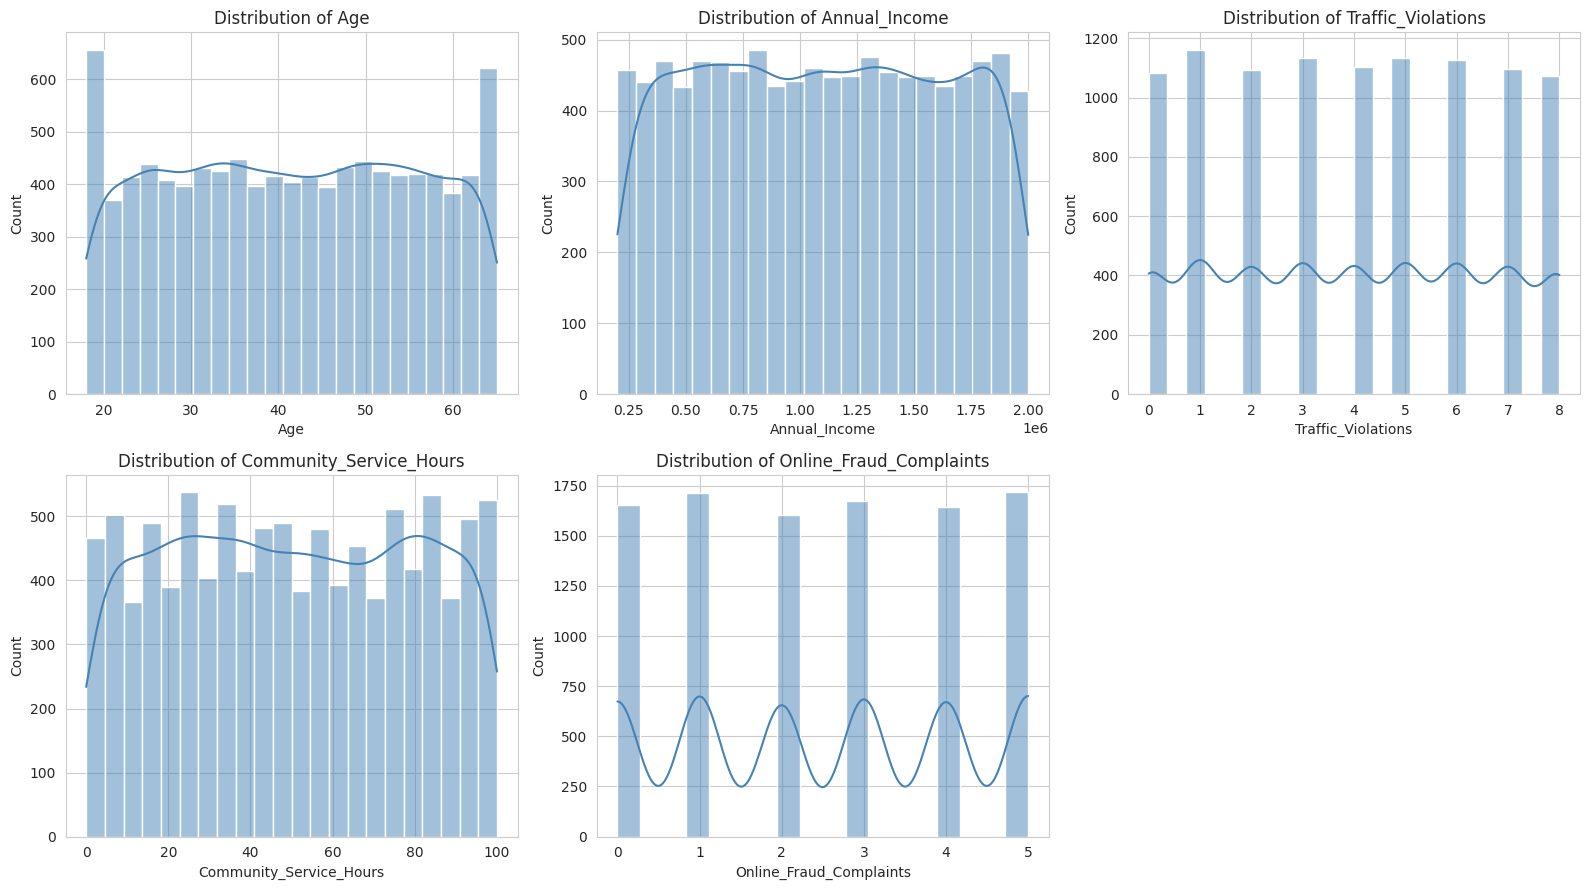

In [ ]:

numeric_cols = ['Age', 'Annual_Income', 'Traffic_Violations',
                 'Community_Service_Hours', 'Online_Fraud_Complaints']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribution of {col}')
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


/tmp/ipykernel_3679/3507313646.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='pastel')
/tmp/ipykernel_3679/3507313646.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='pastel')
/tmp/ipykernel_3679/3507313646.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=df, ax=axes[i], palette='pastel')
/tmp/ipykernel_3679/3507313646.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `

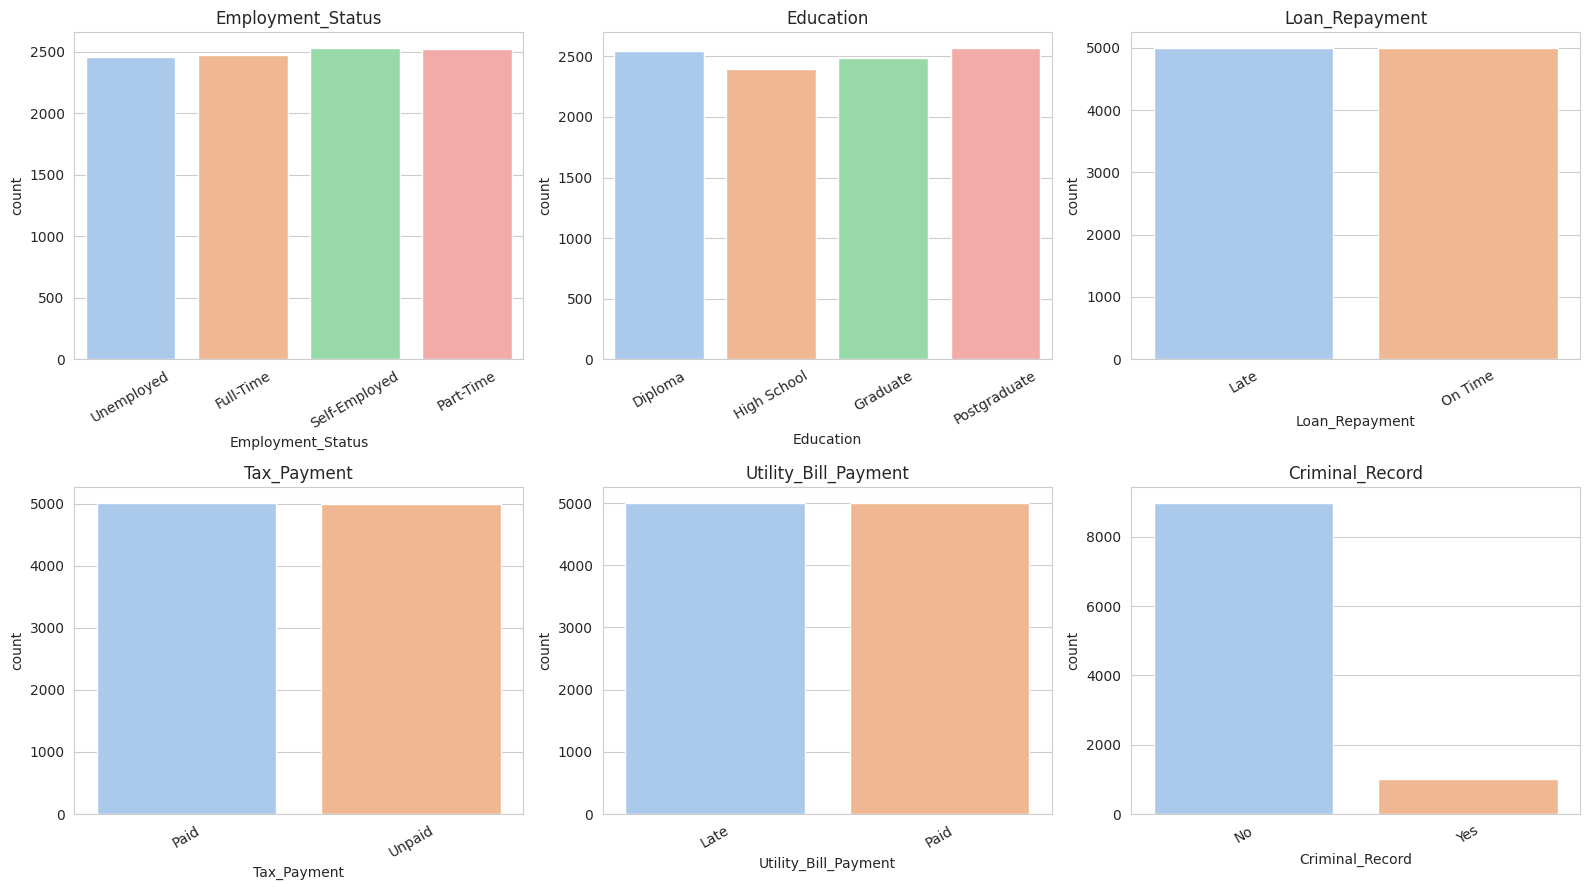

In [ ]:

cat_cols = ['Employment_Status', 'Education', 'Loan_Repayment',
            'Tax_Payment', 'Utility_Bill_Payment', 'Criminal_Record']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(x=col, data=df, ax=axes[i], palette='pastel')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


/tmp/ipykernel_3679/1355388308.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Social_Credit_Score', y='Annual_Income', data=df, order=order, ax=axes[0], palette='viridis')
/tmp/ipykernel_3679/1355388308.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Social_Credit_Score', y='Traffic_Violations', data=df, order=order, ax=axes[1], palette='viridis')


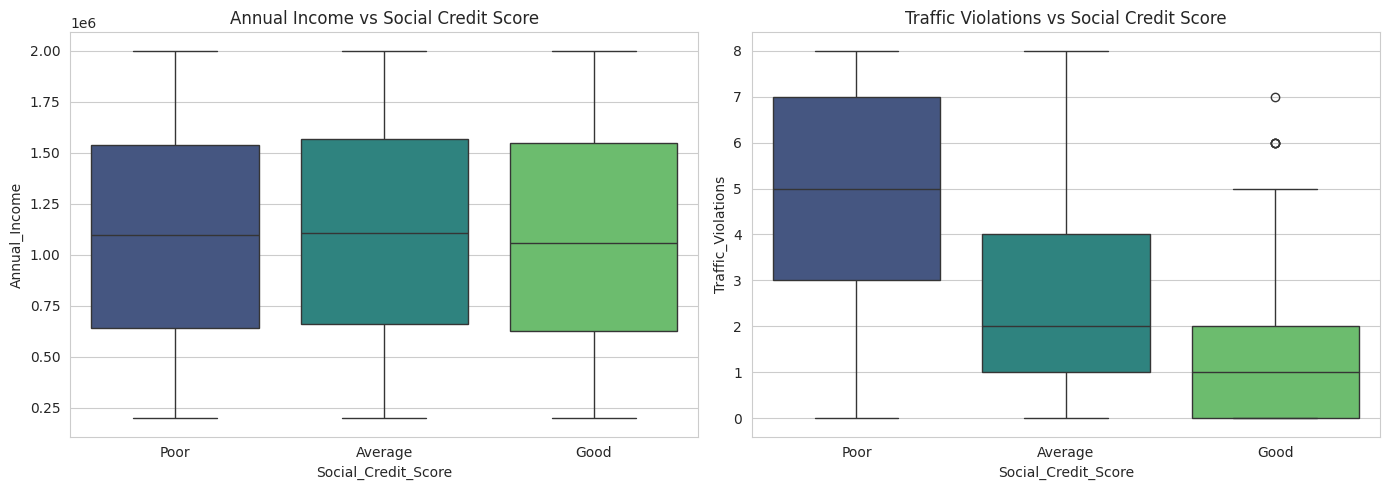

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='Social_Credit_Score', y='Annual_Income', data=df, order=order, ax=axes[0], palette='viridis')
axes[0].set_title('Annual Income vs Social Credit Score')

sns.boxplot(x='Social_Credit_Score', y='Traffic_Violations', data=df, order=order, ax=axes[1], palette='viridis')
axes[1].set_title('Traffic Violations vs Social Credit Score')
plt.tight_layout()
plt.show()


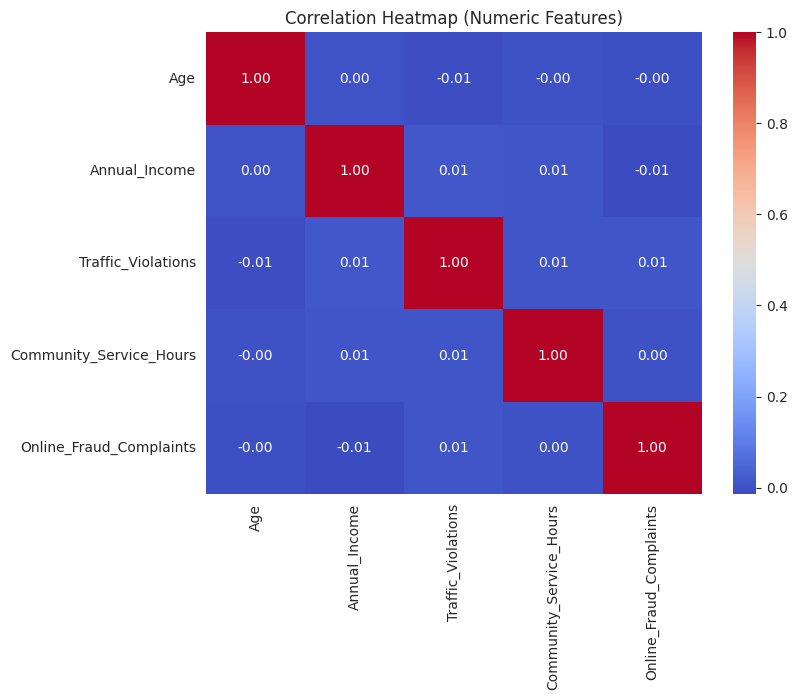

In [ ]:

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()


In [ ]:
df_model = df.copy()


binary_cat_cols = ['Loan_Repayment', 'Tax_Payment', 'Utility_Bill_Payment', 'Criminal_Record']
le_dict = {}
for col in binary_cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    le_dict[col] = le

df_model = pd.get_dummies(df_model, columns=['Employment_Status', 'Education'], drop_first=True)

target_map = {'Poor': 0, 'Average': 1, 'Good': 2}
df_model['Social_Credit_Score'] = df_model['Social_Credit_Score'].map(target_map)

df_model.head()


,Age,Annual_Income,Loan_Repayment,Tax_Payment,Utility_Bill_Payment,Traffic_Violations,Criminal_Record,Community_Service_Hours,Online_Fraud_Complaints,Social_Credit_Score,Employment_Status_Part-Time,Employment_Status_Self-Employed,Employment_Status_Unemployed,Education_Graduate,Education_High School,Education_Postgraduate
0,65,475450,0,0,0,6,0,83,3,0,False,False,True,False,False,False
1,19,1672440,1,0,1,7,0,81,5,0,False,False,False,False,True,False
2,30,652940,1,1,0,6,0,9,4,0,False,False,False,False,True,False
3,33,917925,1,0,1,0,0,45,2,2,False,False,True,False,True,False
4,46,1054846,1,0,1,0,0,22,0,2,False,False,False,False,False,False


In [ ]:
X = df_model.drop(columns=['Social_Credit_Score'])
y = df_model['Social_Credit_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (8000, 15)
Test shape: (2000, 15)


In [ ]:

scaler = StandardScaler()
num_features_to_scale = ['Age', 'Annual_Income', 'Traffic_Violations',
                          'Community_Service_Hours', 'Online_Fraud_Complaints']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[num_features_to_scale] = scaler.fit_transform(X_train[num_features_to_scale])
X_test_scaled[num_features_to_scale] = scaler.transform(X_test[num_features_to_scale])


In [ ]:
models = {}

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
models['Logistic Regression'] = (log_reg, X_test_scaled)

dt = DecisionTreeClassifier(max_depth=8, random_state=42)
dt.fit(X_train, y_train)
models['Decision Tree'] = (dt, X_test)


rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
models['Random Forest'] = (rf, X_test)

print("Models trained: ", list(models.keys()))


Models trained:  ['Logistic Regression', 'Decision Tree', 'Random Forest']


## 5. Model Evaluation

/tmp/ipykernel_3679/3261812100.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')


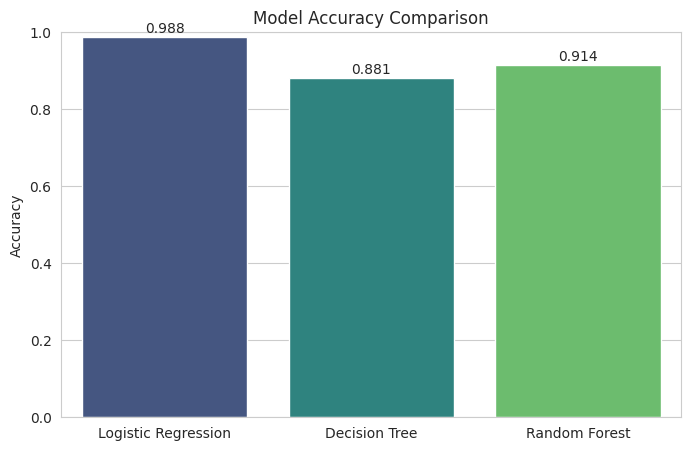

In [ ]:

plt.figure()
sns.barplot(x=list(results.keys()), y=list(results.values()), palette='viridis')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
plt.show()


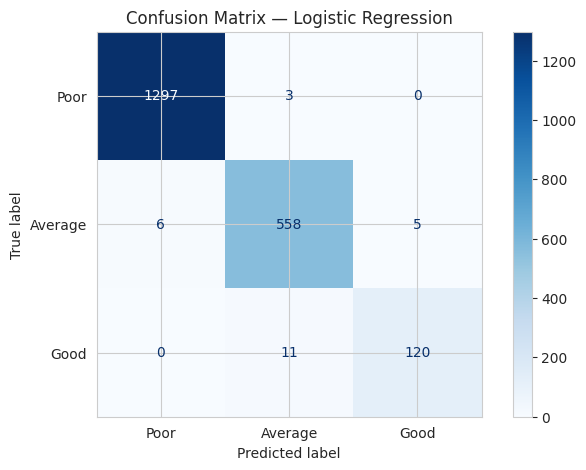

Best performing model: Logistic Regression (Accuracy: 0.9875)


In [ ]:

best_model_name = max(results, key=results.get)
best_model, X_te_best = models[best_model_name]
preds_best = best_model.predict(X_te_best)

cm = confusion_matrix(y_test, preds_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Poor', 'Average', 'Good'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.show()

print(f"Best performing model: {best_model_name} (Accuracy: {results[best_model_name]:.4f})")


## 6. Feature Importance & Conclusions

In [ ]:

if best_model_name in ['Random Forest', 'Decision Tree']:
    importances = pd.Series(best_model.feature_importances_, index=X_te_best.columns)
    importances = importances.sort_values(ascending=False).head(10)

    plt.figure(figsize=(8, 6))
    sns.barplot(x=importances.values, y=importances.index, palette='viridis')
    plt.title(f'Top 10 Feature Importances — {best_model_name}')
    plt.xlabel('Importance')
    plt.show()
else:
    print("Feature importance plot only shown for tree-based models.")


Feature importance plot only shown for tree-based models.


In [ ]:
results = {}
for name, (model, X_te) in models.items():
    preds = model.predict(X_te)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, preds, target_names=['Poor', 'Average', 'Good']))
    print()

--- Logistic Regression ---
Accuracy: 0.9875
              precision    recall  f1-score   support

        Poor       1.00      1.00      1.00      1300
     Average       0.98      0.98      0.98       569
        Good       0.96      0.92      0.94       131

    accuracy                           0.99      2000
   macro avg       0.98      0.96      0.97      2000
weighted avg       0.99      0.99      0.99      2000


--- Decision Tree ---
Accuracy: 0.8815
              precision    recall  f1-score   support

        Poor       0.93      0.94      0.93      1300
     Average       0.78      0.81      0.80       569
        Good       0.85      0.63      0.72       131

    accuracy                           0.88      2000
   macro avg       0.85      0.79      0.82      2000
weighted avg       0.88      0.88      0.88      2000


--- Random Forest ---
Accuracy: 0.9145
              precision    recall  f1-score   support

        Poor       0.93      0.99      0.96      1300
    

In [ ]:
import pickle
model.fit(X_train, y_train)
with open("model.pkl", "wb") as file:
    pickle.dump(model, file)
print("Model saved successfully as model.pkl")

Model saved successfully as model.pkl


In [ ]:
from google.colab import files
files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>